# Obligatorio — Análisis Predictivo de Series Temporales — Curso 2026

## Posgrado de Big Data e Inteligencia Artificial — Universidad ORT Uruguay

---

**Fecha de entrega:** 6/7/2026 por el sistema de Gestión.

Se debe entregar un PDF con los avances a la fecha. Pueden seguir trabajando en el repo y solución hasta el 13/7/2026.

---

### Integrantes:

* (completar)
*
*

---

## Introducción

En este obligatorio se analiza la serie de consumo eléctrico diario de la región **PJME** (PJM East), que corresponde a una parte de la red de transmisión eléctrica del este de los Estados Unidos, operada por PJM Interconnection LLC.

Los datos cubren el período **2002–2017** (16 años completos, ~5800 observaciones diarias) y provienen del dataset público disponible en [Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption), aquí ya procesados a frecuencia diaria.

El objetivo del trabajo es construir, evaluar y comparar distintos modelos de predicción para esta serie, incorporando progresivamente más estructura. Para ello, el trabajo se organiza en varias partes, buscando construir diferentes modelos y poder comparar su poder predictivo. Se sugiere tomar como datos de entrenamiento los datos hasta 2015 y utilizar los últimos 2 años para test.

## Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [14, 4]
plt.rcParams['axes.grid'] = True

In [2]:
# Cargar datos
data = pd.read_csv('data/pjme_daily.csv', parse_dates=['date'], index_col='date')
data.index.freq = 'D' #le asigno frecuencia diaria al indice
pjme=pd.Series(data["consumo_MW"])
print(f"Serie cargada: {len(pjme)} observaciones ({pjme.index.min().date()} a {pjme.index.max().date()})")
pjme.head()

Serie cargada: 5844 observaciones (2002-01-01 a 2017-12-31)


date
2002-01-01    31080.7
2002-01-02    34261.5
2002-01-03    34511.9
2002-01-04    33715.5
2002-01-05    30405.1
Freq: D, Name: consumo_MW, dtype: float64

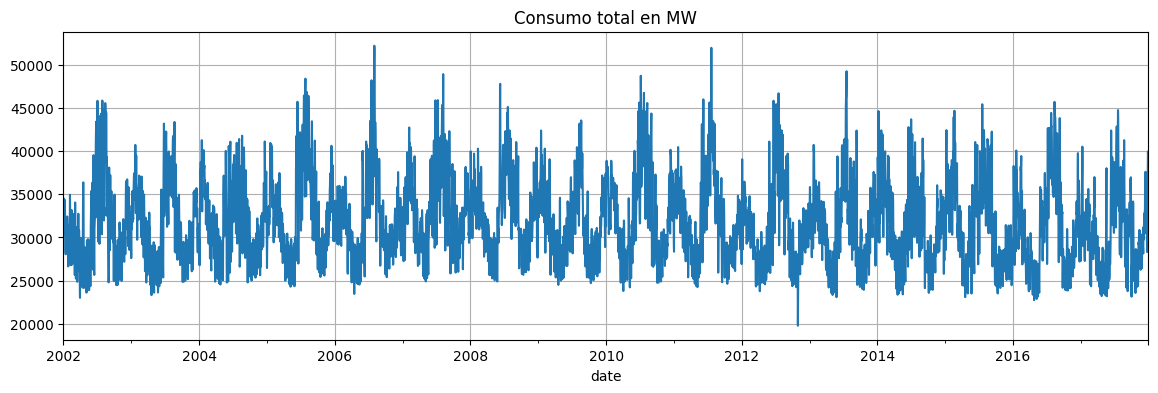

In [3]:
pjme.plot();
plt.title("Consumo total en MW");

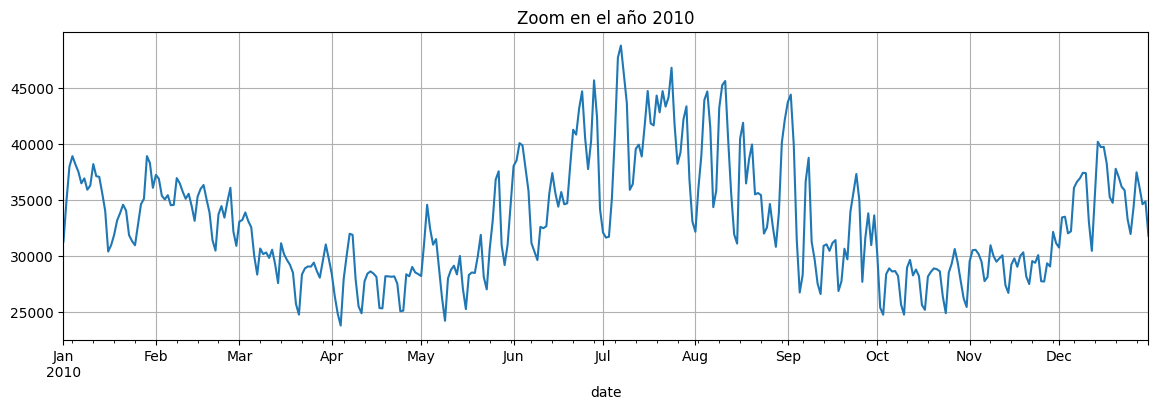

In [4]:
zoom = pjme['2010']
zoom.plot()
plt.title("Zoom en el año 2010");

## Parte I — Análisis exploratorio

En esta parte se busca construir un modelo que capture el comportamiento sistemático de la serie a partir de funciones del tiempo. En particular se debe explorar:

 * Si la serie presenta tendencias visibles.
 * Si la serie presenta correlaciones de corto o largo plazo.
 * Si hay efectos estacionales o periódicos regulares. *Sugerencia:* observe que las series presentan *2 picos* por año correspondientes a los picos de consumo en invierno y verano respectivamente.
 * Si hay efectos de días especiales, por ejemplo fines de semana donde hay menos consumo. *Sugerencia:* Agrupe la serie por día de la semana y realice un `boxplot` para ver el comportamiento.

En base a los efectos anteriores, proponga un modelo lineal adecuado para la serie. Analice los resultados del ajuste, discuta el comportamiento de los residuos sobre el conjunto de entrenamiento, calcule el RMSE del ajuste y el RMSE del modelo en los datos de test.

## Parte II — Modelos con correlación interna

El modelo de regresión de la Parte I no tiene en cuenta la estructura de autocorrelación de los residuos. Buscamos ahora incorporar una componente ARMA a los mismos.

 * Analice los residuos del ajuste anterior, en particular su estructura de correlación.
 * En base a dicho análisis, proponga un modelo $ARMA(p,q)$ adecuadamente justificado (puede probar más de uno para comparar).
 * Realice el ajuste sobre los residuos y haga un diagnóstico sobre el ajuste realizado.

## Parte III — Modelo ARMA con variables exógenas.

Combine los resultados de las partes I y II realizando un ajuste ARMA con variables exógenas, donde las variables exógenas son exactamente los regresores usados en la formulación lineal.

* Analice si el modelo mejora el ajuste respecto a la Parte I.
* Realice un diagnóstico de los residuos finales.
* Calcule la predicción sobre los datos de test y reporte los resultados.


## Parte IV — Modelo en espacio de estados

Consideramos ahora un enfoque por modelos estructurales para la serie. Para toda esta parte conviene trabajar con la serie *centrada*, restando la media.

1. En primer lugar se propone un modelo de la forma *local level* de ruido $w_t$ más una componente estacional:
   \begin{align*}
   x_{t+1} &= x_t + \overbrace{\eta_t}^{\text{level noise}} \\
   y_t &= x_t + s_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $s_t$ es una componente estacional de corto plazo que modela la variación intrasemanal. Es decir $\sum_{j=0}^6 s_{t-j} = w_t$, con $w_t$ el ruido blanco estacional (seasonal noise) y $\varepsilon_t$ el ruido blanco de observación (irregular noise).
   Esto puede hacerse mediante `UnobservedComponents` pasando como parámetros `seasonal=7` y `stochastic_seasonal=True`.
   Ajuste este modelo y observe que la componente de tendencia está intentando trackear la variación anual.

3. Mejore el modelo anterior incorporando una componente *determinística* de frecuencia como la de la parte I (cosenos y senos de frecuencia adecuada). Es decir:
   \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $\mu$ es un nivel determinístico, $s_t$ es como antes y $\gamma_t$ son los cosenos y senos de la parte I.

   Esto puede hacerse mediante `UnobservedComponents` agregando como parámetros `freq_seasonal=[{'period': 365.25, 'harmonics': k}]` donde $k$ es la cantidad de componentes de frecuencia, y `stochastic_freq_seasonal=[False]`. Para la componente determinística puede usarse `level=True, stochastic_level=False`. Verifique que la performance de este modelo es comparable a la de la regresión lineal de la parte I, y el residuo aún no queda blanco.


4. Incorpore una componente autorregresiva al modelo cambiando la parte `irregular` por una autorregresiva, es decir:
    \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{autoregressive noise}}
   \end{align*}
   donde ahora $\varepsilon_t$ es un proceso autorregresivo de orden similar al de la parte II. Para ello puede colocar como parámetros `irregular=False` y `autorregresive=k` con $k$ adecuado.

   
5. Compare este último modelo con el obtenido en la parte III en los datos de test y discuta.
   
   

## Parte V — Correlación con temperatura

El consumo eléctrico está fuertemente influenciado por la temperatura: el frío aumenta la demanda de calefacción, el calor aumenta la de refrigeración. En esta parte se estudia cuantitativamente esa relación y se evalúa si incorporar temperatura mejora la predicción. Para ello disponemos como referencia los datos de temperatura de Philadelphia, en el centro de la zona de influencia de PJM-East.

In [5]:
temp = pd.read_csv('data/philadelphia_temp.csv', parse_dates=['date'], index_col='date')
print(f"Temperatura cargada: {len(temp)} días")

temp.head()

Temperatura cargada: 5844 días


,temp_C,temp_max_C,temp_min_C
date,,,
2002-01-01,-3.3,1.3,-6.6
2002-01-02,-2.4,2.3,-5.7
2002-01-03,-1.2,3.1,-4.0
2002-01-04,-0.4,3.6,-2.6
2002-01-05,1.2,5.8,-1.4


<Axes: xlabel='date'>

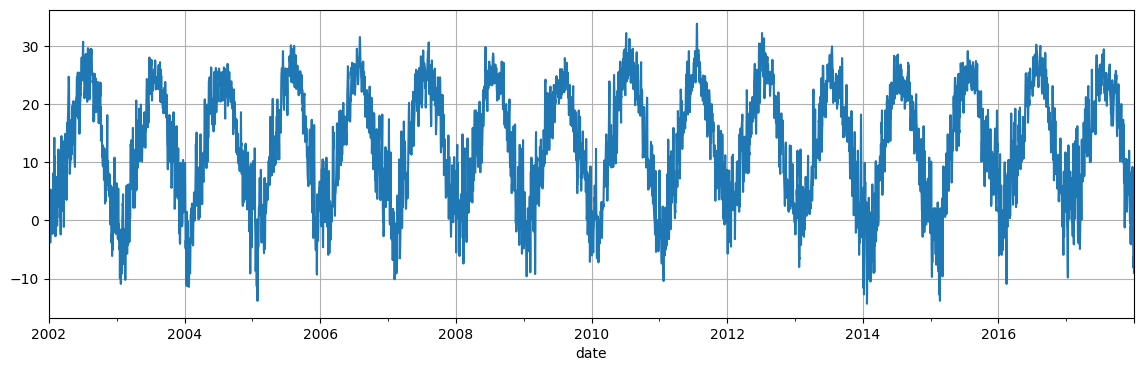

In [6]:
temp["temp_C"].plot()

1. Grafique simultáneamente ambas series para ver su comportamiento conjunto.
2. Estudie la correlación a lag 0 entre $P_t=pjme_t$ y $T_t=temp_t$. ¿Es alta la correlación?
3. Realice un scatter plot entre $pjme_t$ y $temp_t$ para ver que hay dependencia *no lineal* más allá de su baja correlación. Interprete el resultado.
4. Para modelar lo anterior, construya una variable explicativa *desvío térmico*, por ejemplo de la forma $\delta_t = |T_t - \bar{T}_t|$.
5. Realice un ajuste por modelo lineal de la forma:
   $$x_t = \beta_0 + \beta_1 \delta_t + \beta_2 d_t + w_t$$
   siendo $d_t$ la dummy de fin de semana y $w_t$ ruido blanco. ¿Cómo se compara este modelo con los anteriores?
6. Proponga formas alternativas de modelar el desvío térmico y/o la variación temporal para mejorar aún más el modelo.